Parkinson’s Disease (PD) is a degenerative neurological disorder marked by decreased dopamine levels in the brain. It manifests itself through a deterioration of movement, including the presence of tremors and stiffness. There is commonly a marked effect on speech, including dysarthria (difficulty articulating sounds), hypophonia (lowered volume), and monotone (reduced pitch range). Additionally, cognitive impairments and changes in mood can occur, and risk of dementia is increased.

Traditional diagnosis of Parkinson’s Disease involves a clinician taking a neurological history of the patient and observing motor skills in various situations. Since there is no definitive laboratory test to diagnose PD, diagnosis is often difficult, particularly in the early stages when motor effects are not yet severe. Monitoring progression of the disease over time requires repeated clinic visits by the patient. An effective screening process, particularly one that doesn’t require a clinic visit, would be beneficial. Since PD patients exhibit characteristic vocal features, voice recordings are a useful and non-invasive tool for diagnosis. If machine learning algorithms could be applied to a voice recording dataset to accurately diagnosis PD, this would be an effective screening step prior to an appointment with a clinician.

The data & attributes information for this project is available at https://archive.ics.uci.edu/ml/machine-learning-databases/parkinsons/ (Links to an external site.)Links to an external site. The data consists of those diagnosed with Parkinson Disease and those who do not.

Steps to be followed:

1. Use a Python notebook & Load the dataset
2. It is always a good practice to eye-ball raw data to get a feel of the data in terms of number of structure of the file, number of attributes, types of attributes and a general idea of likely challenges in the dataset. (2.5 points)
3. Using univariate & bivariate analysis to check the individual attributes for their basic statistic such as central values, spread, tails etc. What are your observations? (15 points)
4. Split the dataset into training and test set in the ratio of 70:30 (Training:Test).
5. Create the model using “entropy” method of reducing the entropy and fit it to training data. (5 points)
6. Test the model on test data and what is the accuracy achieved. Capture the predicted values and do a crosstab. (7.5 points)
7. Use regularization parameters of max_depth, min_sample_leaf to recreate the model. What is the impact on the model accuracy? How does regularization help? (20 points) 
8. Next implement the decision tree using Random Forest. What is the optimal number of trees that gives the best result? (10 points)


# 1. Use a Python notebook & Load the dataset

In [1]:
#import the python libraries
import pandas as pd
import numpy as np

In [28]:
from sklearn import tree, metrics
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, classification_report, mean_squared_error
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cross_validation import cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score
from sklearn.metrics import f1_score, auc, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn import model_selection

from scipy.stats import zscore

In [3]:
#Import graph plotting libraries
import matplotlib as mp
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set(style="ticks")

In [4]:
df = pd.read_csv("parkinsons.data")

# 2. It is always a good practice to eye-ball raw data to get a feel of the data in terms of number of structure of the file, number of attributes, types of attributes and a general idea of likely challenges in the dataset. (2.5 points)

In [5]:
df.shape

(195, 24)

In [6]:
df.columns

Index(['name', 'MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)',
       'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP',
       'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5',
       'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'status', 'RPDE', 'DFA',
       'spread1', 'spread2', 'D2', 'PPE'],
      dtype='object')

In [7]:
df.head(5).T #print some random rows

,0,1,2,3,4
name,phon_R01_S01_1,phon_R01_S01_2,phon_R01_S01_3,phon_R01_S01_4,phon_R01_S01_5
MDVP:Fo(Hz),119.992,122.4,116.682,116.676,116.014
MDVP:Fhi(Hz),157.302,148.65,131.111,137.871,141.781
MDVP:Flo(Hz),74.997,113.819,111.555,111.366,110.655
MDVP:Jitter(%),0.00784,0.00968,0.0105,0.00997,0.01284
MDVP:Jitter(Abs),7e-05,8e-05,9e-05,9e-05,0.00011
MDVP:RAP,0.0037,0.00465,0.00544,0.00502,0.00655
MDVP:PPQ,0.00554,0.00696,0.00781,0.00698,0.00908
Jitter:DDP,0.01109,0.01394,0.01633,0.01505,0.01966
MDVP:Shimmer,0.04374,0.06134,0.05233,0.05492,0.06425


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
name                195 non-null object
MDVP:Fo(Hz)         195 non-null float64
MDVP:Fhi(Hz)        195 non-null float64
MDVP:Flo(Hz)        195 non-null float64
MDVP:Jitter(%)      195 non-null float64
MDVP:Jitter(Abs)    195 non-null float64
MDVP:RAP            195 non-null float64
MDVP:PPQ            195 non-null float64
Jitter:DDP          195 non-null float64
MDVP:Shimmer        195 non-null float64
MDVP:Shimmer(dB)    195 non-null float64
Shimmer:APQ3        195 non-null float64
Shimmer:APQ5        195 non-null float64
MDVP:APQ            195 non-null float64
Shimmer:DDA         195 non-null float64
NHR                 195 non-null float64
HNR                 195 non-null float64
status              195 non-null int64
RPDE                195 non-null float64
DFA                 195 non-null float64
spread1             195 non-null float64
spread2             195 non-null floa

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MDVP:Fo(Hz),195.0,154.228641,41.390065,88.333000,117.572000,148.790000,182.769000,260.105000
MDVP:Fhi(Hz),195.0,197.104918,91.491548,102.145000,134.862500,175.829000,224.205500,592.030000
MDVP:Flo(Hz),195.0,116.324631,43.521413,65.476000,84.291000,104.315000,140.018500,239.170000
MDVP:Jitter(%),195.0,0.006220,0.004848,0.001680,0.003460,0.004940,0.007365,0.033160
MDVP:Jitter(Abs),195.0,0.000044,0.000035,0.000007,0.000020,0.000030,0.000060,0.000260
MDVP:RAP,195.0,0.003306,0.002968,0.000680,0.001660,0.002500,0.003835,0.021440
MDVP:PPQ,195.0,0.003446,0.002759,0.000920,0.001860,0.002690,0.003955,0.019580
Jitter:DDP,195.0,0.009920,0.008903,0.002040,0.004985,0.007490,0.011505,0.064330
MDVP:Shimmer,195.0,0.029709,0.018857,0.009540,0.016505,0.022970,0.037885,0.119080
MDVP:Shimmer(dB),195.0,0.282251,0.194877,0.085000,0.148500,0.221000,0.350000,1.302000


## Class Distribution

In [10]:
df.groupby(["status"]).count().T

status,0,1
name,48,147
MDVP:Fo(Hz),48,147
MDVP:Fhi(Hz),48,147
MDVP:Flo(Hz),48,147
MDVP:Jitter(%),48,147
MDVP:Jitter(Abs),48,147
MDVP:RAP,48,147
MDVP:PPQ,48,147
Jitter:DDP,48,147
MDVP:Shimmer,48,147


In [11]:
x = df['status'].value_counts()
x

1    147
0     48
Name: status, dtype: int64

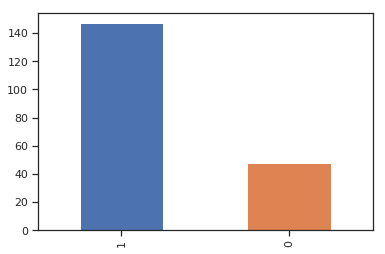

In [12]:
x.plot.bar()

In [13]:
x[1]/x[0]

3.0625

### Observation

#### Most people are healthy, without Parkinsons Disease. The ratio is almost 3:1 in favor or class 0.   The model's ability to predict class 1 will be better than predicting class 0. 

# 3. Using univariate & bivariate analysis to check the individual attributes for their basic statistic such as central values, spread, tails etc. What are your observations? (15 points)

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.0037,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654


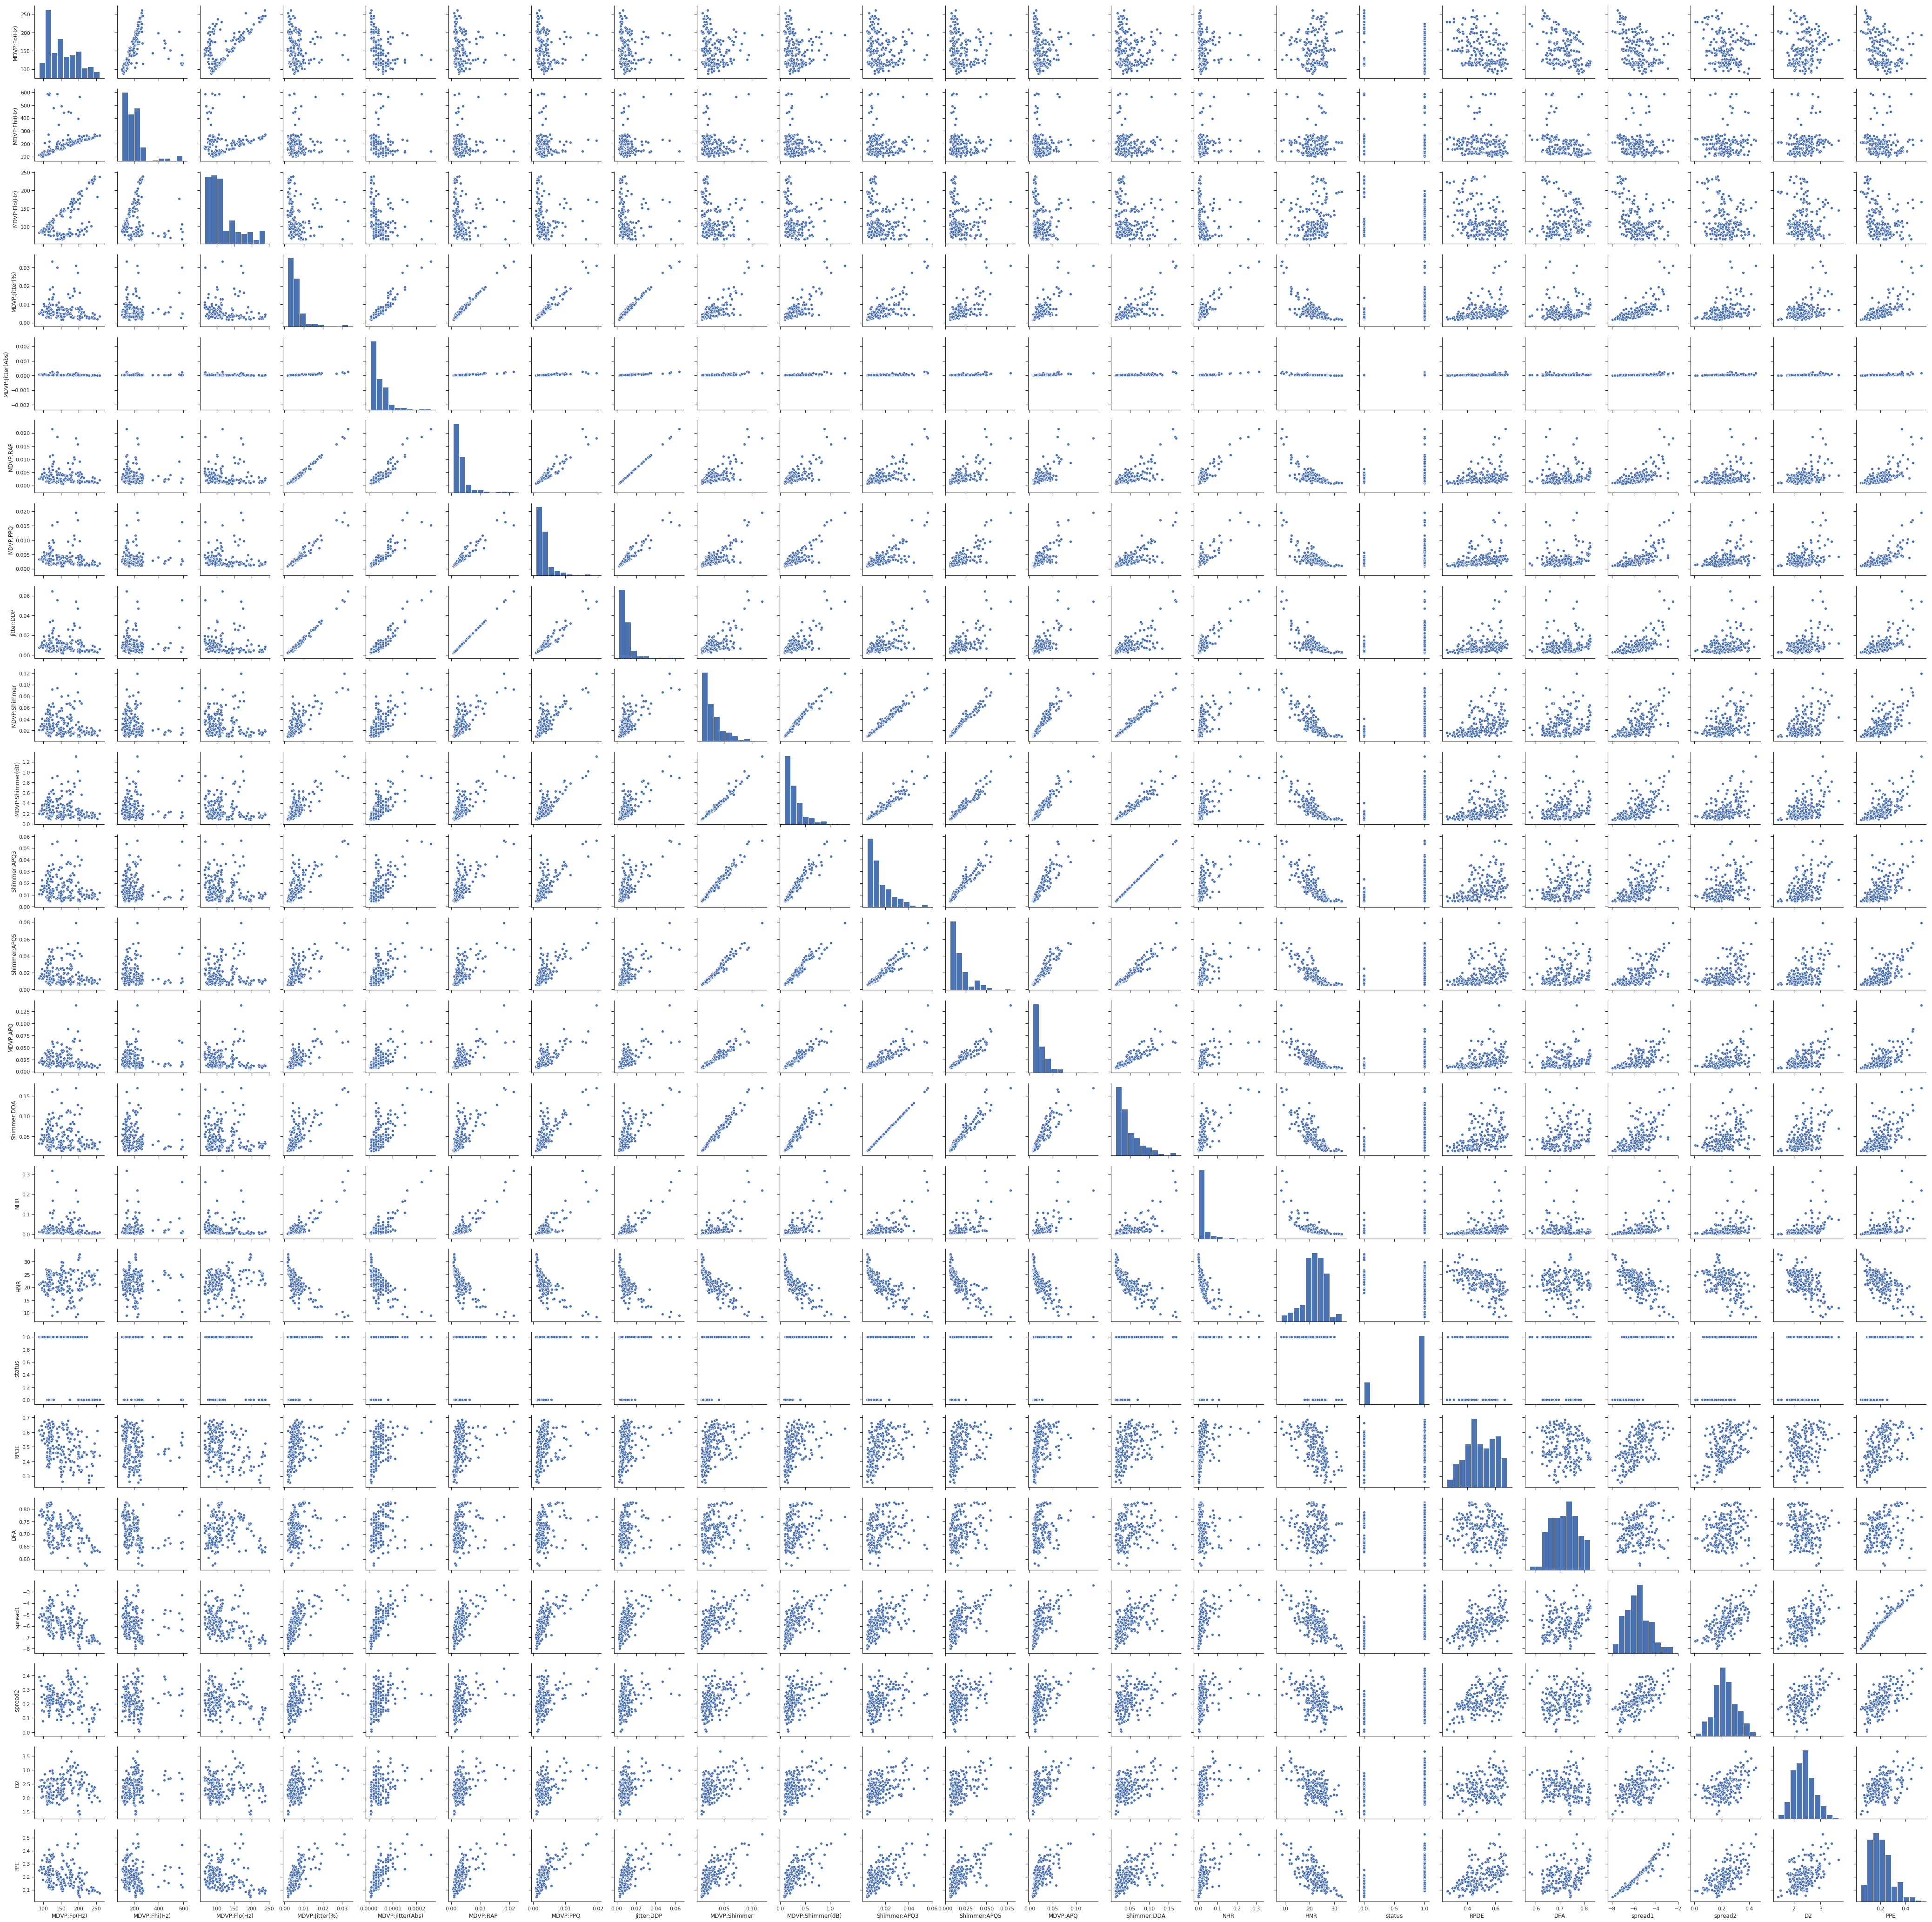

In [14]:
sns.pairplot(df)
df.head(1)

## Correlation comparison with heat map¶

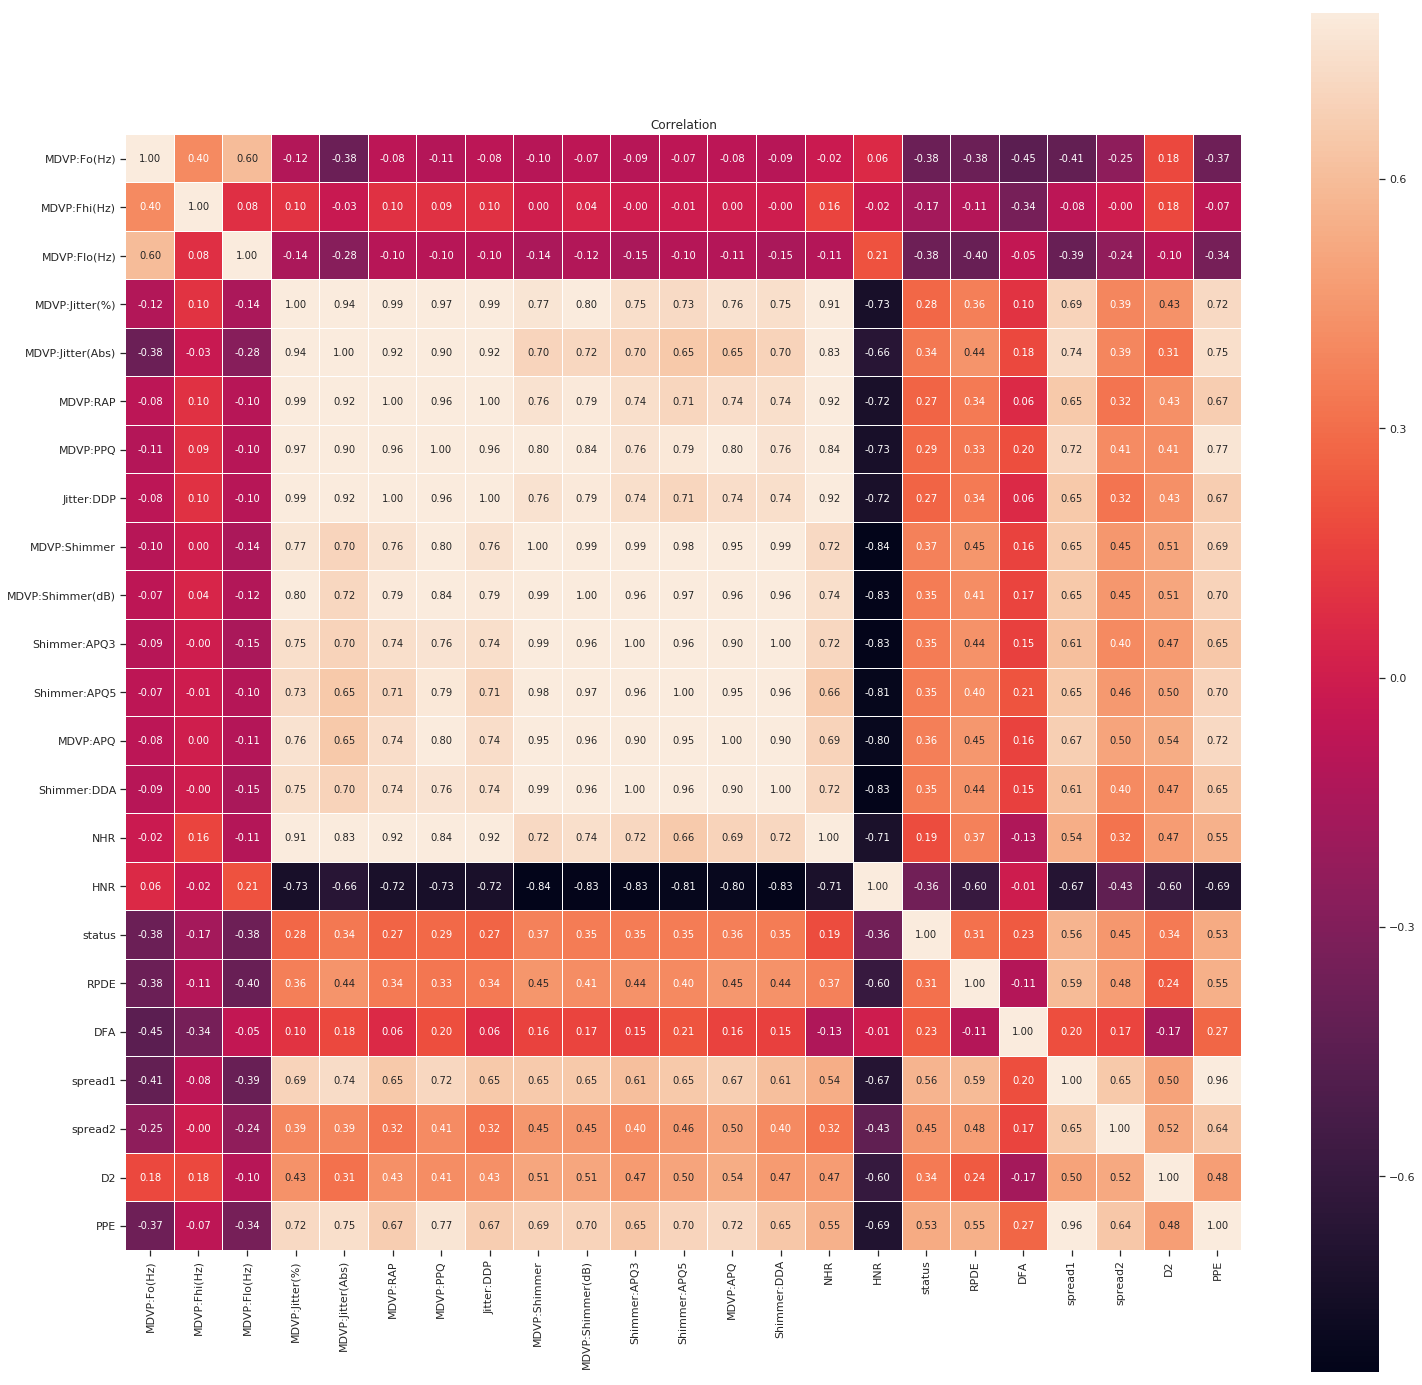

In [15]:
from matplotlib import pyplot as plt
plt.figure(figsize=(25, 25))
ax = sns.heatmap(df.corr(), vmax=.8, square=True, fmt='.2f', annot=True, linecolor='white', linewidths=0.01)
plt.title('Correlation')
plt.show()

# 4. Split the dataset into training and test set in the ratio of 70:30 (Training:Test).

In [16]:
#Drop highly correlated columns & target variable
X = df.drop(['name', 'status'], axis=1)

y =  df.pop("status")
X_std = StandardScaler().fit_transform(X)
train_set, test_set, train_labels, test_labels = train_test_split(X_std, y, test_size=0.30, random_state=0)



In [17]:
train_set

array([[-0.43287297, -0.22474984, -1.16505431, ..., -0.01993408,
         0.68213418,  0.40527522],
       [ 2.01040987,  0.5503279 ,  2.50871184, ..., -1.53696175,
         0.09169833, -1.24065173],
       [ 1.81040406,  0.46501905, -0.07195702, ..., -2.64733793,
        -0.68941562, -1.27943335],
       ...,
       [-0.82716807, -0.62893955, -0.11786844, ...,  1.2327641 ,
        -0.46305543, -0.2043838 ],
       [-0.29216402,  0.22299834, -0.7640147 , ..., -0.19623788,
        -0.46168828,  0.31191454],
       [ 1.04981516,  0.22488313, -0.58813225, ..., -0.74504311,
         1.3111645 , -0.04085799]])

In [18]:
train_set.shape, test_set.shape, train_labels.shape, test_labels.shape

((136, 22), (59, 22), (136,), (59,))

# 5. Create the model using “entropy” method of reducing the entropy and fit it to training data. (5 points)

In [19]:
dt_model = DecisionTreeClassifier(criterion='entropy',random_state=0)#fully grown tree (high bias error and var error)
dt_model.fit(train_set, train_labels)

DecisionTreeClassifier(class_weight=None, criterion='entropy', max_depth=None,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=0,
            splitter='best')

# 6. Test the model on test data and what is the accuracy achieved. Capture the predicted values and do a crosstab. (7.5 points)

In [20]:
y_predict_dt = dt_model.predict(test_set)

In [21]:
dt_acc=metrics.accuracy_score(test_labels, y_predict_dt)
print(dt_acc)

0.8135593220338984


In [22]:
dt_cr = metrics.classification_report(test_labels , y_predict_dt)
print(dt_cr)

             precision    recall  f1-score   support

          0       0.54      0.58      0.56        12
          1       0.89      0.87      0.88        47

avg / total       0.82      0.81      0.82        59



### Importance of features in the tree building 
(The importance of a feature is computed as the (normalized) total reduction of the criterion brought by that feature. It is also known as the Gini importance )

In [37]:
print (pd.Series(dt_model.feature_importances_, index = list(X)).sort_values(ascending=False))

PPE                 0.432452
MDVP:Fo(Hz)         0.167122
MDVP:Fhi(Hz)        0.135567
spread2             0.096151
MDVP:APQ            0.060877
D2                  0.057237
DFA                 0.050594
Jitter:DDP          0.000000
MDVP:Flo(Hz)        0.000000
MDVP:Jitter(%)      0.000000
MDVP:Jitter(Abs)    0.000000
MDVP:RAP            0.000000
MDVP:PPQ            0.000000
MDVP:Shimmer(dB)    0.000000
MDVP:Shimmer        0.000000
spread1             0.000000
Shimmer:APQ5        0.000000
Shimmer:DDA         0.000000
NHR                 0.000000
HNR                 0.000000
RPDE                0.000000
Shimmer:APQ3        0.000000
dtype: float64


# 7. Use regularization parameters of max_depth, min_sample_leaf to recreate the model. What is the impact on the model accuracy? How does regularization help? (20 points) 

In [23]:
#Regularized Tree (comparatively var error is reduced)
dt_model_reg = DecisionTreeClassifier(criterion = 'entropy', max_depth=4, min_samples_leaf=2, random_state=0 )
dt_model_reg.fit(train_set, train_labels)
y_predict_dt_reg = dt_model_reg.predict(test_set)
print(dt_model_reg)
dt_reg_acc = metrics.accuracy_score(test_labels, y_predict_dt_reg)
print(dt_reg_acc)
dt_reg_cr = metrics.classification_report(test_labels , y_predict_dt_reg)
print(dt_reg_cr)

DecisionTreeClassifier(class_weight=None, criterion='entropy', max_depth=4,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=2, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=0,
            splitter='best')
0.6949152542372882
             precision    recall  f1-score   support

          0       0.36      0.67      0.47        12
          1       0.89      0.70      0.79        47

avg / total       0.78      0.69      0.72        59



### Importance of features in the tree building 
(The importance of a feature is computed as the (normalized) total reduction of the criterion brought by that feature. It is also known as the Gini importance )

In [35]:
print (pd.Series(dt_model_reg.feature_importances_,index = list(X)).sort_values(ascending=False))

PPE                 0.488181
MDVP:Fhi(Hz)        0.153038
MDVP:Fo(Hz)         0.124404
spread2             0.108542
MDVP:APQ            0.068722
DFA                 0.057113
spread1             0.000000
Jitter:DDP          0.000000
MDVP:Flo(Hz)        0.000000
MDVP:Jitter(%)      0.000000
MDVP:Jitter(Abs)    0.000000
MDVP:RAP            0.000000
MDVP:PPQ            0.000000
MDVP:Shimmer(dB)    0.000000
MDVP:Shimmer        0.000000
D2                  0.000000
Shimmer:APQ5        0.000000
Shimmer:DDA         0.000000
NHR                 0.000000
HNR                 0.000000
RPDE                0.000000
Shimmer:APQ3        0.000000
dtype: float64


# 8. Next implement the decision tree using Random Forest. What is the optimal number of trees that gives the best result? (10 points)

In [24]:
rf_model = RandomForestClassifier(n_estimators=51,criterion='entropy',max_depth=4,random_state=0 )
print(rf_model)

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='entropy',
            max_depth=4, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators=51, n_jobs=1,
            oob_score=False, random_state=0, verbose=0, warm_start=False)


In [25]:
rf_model.fit(train_set, train_labels)
y_predict_rf = rf_model.predict(test_set)
rf_acc = metrics.accuracy_score(test_labels,y_predict_rf)
print(rf_acc)
rf_cr=metrics.classification_report(test_labels , y_predict_rf)
print(rf_cr)

0.8135593220338984
             precision    recall  f1-score   support

          0       0.56      0.42      0.48        12
          1       0.86      0.91      0.89        47

avg / total       0.80      0.81      0.80        59



### Importance of features in the tree building 
(The importance of a feature is computed as the (normalized) total reduction of the criterion brought by that feature. It is also known as the Gini importance )

In [38]:
print (pd.Series(rf_model.feature_importances_, index = list(X)).sort_values(ascending=False))

spread1             0.150636
PPE                 0.132440
spread2             0.091035
MDVP:Fo(Hz)         0.072973
Shimmer:APQ5        0.070419
MDVP:APQ            0.062716
MDVP:Flo(Hz)        0.042609
Jitter:DDP          0.037621
Shimmer:APQ3        0.035600
DFA                 0.035139
MDVP:Fhi(Hz)        0.033293
MDVP:Shimmer        0.029823
D2                  0.029443
MDVP:Shimmer(dB)    0.027761
MDVP:Jitter(Abs)    0.024301
RPDE                0.023400
MDVP:RAP            0.021946
Shimmer:DDA         0.021270
HNR                 0.016113
MDVP:PPQ            0.015922
MDVP:Jitter(%)      0.013623
NHR                 0.011919
dtype: float64


### Analysis of all the above models

In [26]:
models = []
models.append(('DecisionTree', dt_model))
models.append(('DT_Regularized',dt_model_reg))
models.append(('RandomForest', rf_model))

DecisionTree: 0.764103 (0.106834)
DT_Regularized: 0.764103 (0.134120)
RandomForest: 0.789744 (0.169619)


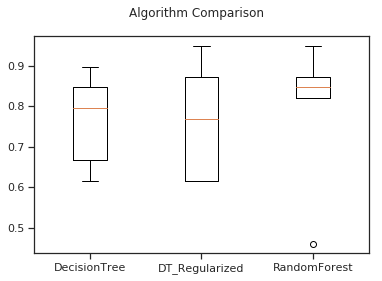

In [29]:
# evaluate each model in turn
results = []
names = []
scoring = 'accuracy'
for name, model in models:
	kfold = model_selection.KFold(n_splits=5,random_state=2)
	cv_results = model_selection.cross_val_score(model, X_std, y, cv=kfold, scoring=scoring)
	results.append(cv_results)
	names.append(name)
	msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
	print(msg)
# boxplot algorithm comparison
fig = plt.figure()
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

### Observation

The accuracy is better for Random Forest compared to Decision Tree as it is using ensembling method. The range of accuracy is small for Random Forest.